### Import and Load Dataset

In [1]:
from darts import TimeSeries
from darts.models import ExponentialSmoothing, ARIMA
from darts.metrics import mape, rmse, mae, r2_score

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
D:\data analytics\TimeSeries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [17]:
import pandas as pd

df = pd.read_csv("../data/cleaned_timeseries.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

print("Date range:", df.index.min(), "to", df.index.max())
print("Total rows:", len(df))

# Check daily frequency
print("Missing dates:",
      pd.date_range(df.index.min(), df.index.max()).difference(df.index))

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Total rows: 454
Missing dates: DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [18]:
df

,unit_sales,day_of_week,is_holiday,locale,holiday_type,dcoilwtico,oil_lag_7,month,month_name,year,...,min_wage,day_of_month,ALLSKY_SFC_SW_DWN,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,is_sunny,is_rainy,solar_7d
date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,582.0,Wednesday,0,NaN,Non-holiday,93.14,NaN,1,January,2013,...,318.0,2,11.06,1.39,16.96,22.68,12.76,0,0,11.060000
2013-01-03,310.0,Thursday,0,NaN,Non-holiday,92.97,NaN,1,January,2013,...,318.0,3,10.07,5.78,17.28,22.80,13.33,0,1,10.565000
2013-01-04,338.0,Friday,0,NaN,Non-holiday,93.12,NaN,1,January,2013,...,318.0,4,12.94,3.32,17.31,22.00,13.09,0,0,11.356667
2013-01-05,654.0,Saturday,1,National,National,93.12,NaN,1,January,2013,...,318.0,5,12.09,5.53,17.78,24.14,12.52,0,1,11.540000
2013-01-06,979.0,Sunday,0,NaN,Non-holiday,93.12,NaN,1,January,2013,...,318.0,6,14.05,5.57,18.02,24.36,13.64,0,1,12.042000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-03-27,328.0,Thursday,0,NaN,Non-holiday,101.25,99.68,3,March,2014,...,340.0,27,14.12,0.20,18.17,23.95,14.02,0,0,11.917143
2014-03-28,523.0,Friday,0,NaN,Non-holiday,101.73,99.97,3,March,2014,...,340.0,28,18.50,0.00,18.19,23.61,14.21,1,0,13.182857
2014-03-29,647.0,Saturday,0,NaN,Non-holiday,101.73,99.97,3,March,2014,...,340.0,29,11.38,0.00,17.93,22.97,14.97,0,0,13.292857


### Convert to Darts TimeSeries

In [19]:
series = TimeSeries.from_series(df["unit_sales"])

train_series = series.slice(pd.Timestamp("2013-01-02"), pd.Timestamp("2013-12-31"))
test_series  = series.slice(pd.Timestamp("2014-01-01"), pd.Timestamp("2014-03-31"))

print("Train length:", len(train_series))
print("Test length :", len(test_series))

Train length: 364
Test length : 90


### Baseline Model

In [20]:
from darts.models import NaiveDrift, NaiveSeasonal

# Simple Naive (last value)
from darts.models import NaiveSeasonal

naive_model = NaiveSeasonal(K=1)  # K=1 = last value
naive_model.fit(train_series)

naive_forecast = naive_model.predict(len(test_series))

In [21]:
## Forecast for all 90 future days = last observed value from training period
from darts.metrics import smape

print("Naive MAE  :", mae(test_series, naive_forecast))
print("Naive RMSE :", rmse(test_series, naive_forecast))
print("Naive sMAPE:", smape(test_series, naive_forecast))

Naive MAE  : 141.54444444444445
Naive RMSE : 195.46136304764798
Naive sMAPE: 30.285165277463626


### Exponential Smoothing (ETS)

In [22]:
# Exponential Smoothing model
ets_model = ExponentialSmoothing()

ets_model.fit(train_series)

ets_forecast = ets_model.predict(len(test_series))

print("ETS MAE  :", mae(test_series, ets_forecast))
print("ETS RMSE :", rmse(test_series, ets_forecast))
print("ETS sMAPE:", smape(test_series, ets_forecast))

ETS MAE  : 98.42344842914801
ETS RMSE : 150.4128069771925
ETS sMAPE: 21.95346325612051


#### ETS is clearly capturing structure (trend/seasonality) that the naive model misses.

### Model 2: ARIMA (Darts)

In [23]:
# ARIMA model (simple starting config)
arima_model = ARIMA(p=3, d=1, q=3)

arima_model.fit(train_series)

arima_forecast = arima_model.predict(len(test_series))

D:\data analytics\TimeSeries\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\data analytics\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
print("ARIMA MAE  :", mae(test_series, arima_forecast))
print("ARIMA RMSE :", rmse(test_series, arima_forecast))
print("ARIMA sMAPE:", smape(test_series, arima_forecast))

ARIMA MAE  : 136.5765288946576
ARIMA RMSE : 184.14459154090162
ARIMA sMAPE: 28.933930604956945


ARIMA barely improves over Naive:
* Only small improvement
* Likely not the correct order
* No seasonal component included

### Third Statistical Model: Improving ARIMA - SARIMA

In [25]:
## Seasonal ARIMA (weekly seasonality = 7)
from darts.models import ARIMA

sarima_model = ARIMA(
    p=1,
    d=1,
    q=1,
    seasonal_order=(1, 1, 1, 7)
)

sarima_model.fit(train_series)
sarima_forecast = sarima_model.predict(len(test_series))

In [26]:
print("SARIMA MAE  :", mae(test_series, sarima_forecast))
print("SARIMA RMSE :", rmse(test_series, sarima_forecast))
print("SARIMA sMAPE:", smape(test_series, sarima_forecast))

SARIMA MAE  : 99.07555859141169
SARIMA RMSE : 151.6648987149044
SARIMA sMAPE: 21.996727016536042


### Theta model

In [27]:
import numpy as np
from darts.models import Theta
from darts.metrics import mae, rmse, smape

eps = 1e-3  # tiny positive constant

# Make strictly positive before log (y + 1 + eps > 0 always, and never equals 1 exactly when y=0)
train_pos = train_series.map(lambda x: x + 1.0 + eps)
test_pos  = test_series.map(lambda x: x + 1.0 + eps)

# Log-transform
train_log = train_pos.map(lambda x: np.log(x))

theta_model = Theta()
theta_model.fit(train_log)

theta_forecast_log = theta_model.predict(len(test_series))

# Invert transform: exp(log(y)) -> y, then undo +1+eps
theta_forecast = theta_forecast_log.map(lambda x: np.exp(x) - 1.0 - eps)

print("THETA (shift+log) MAE  :", mae(test_series, theta_forecast))
print("THETA (shift+log) RMSE :", rmse(test_series, theta_forecast))
print("THETA (shift+log) sMAPE:", smape(test_series, theta_forecast))

THETA (shift+log) MAE  : 121.26091632351945
THETA (shift+log) RMSE : 178.01141235176084
THETA (shift+log) sMAPE: 27.34596601531178


### Prophet

In [28]:
!pip install --upgrade pip setuptools wheel

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
Using cached setuptools-82.0.0-py3-none-any.whl (1.0 MB)
Using cached wheel-0.46.3-py3-none-any.whl (30 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\Marija Pavlova\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip setuptools wheel


In [29]:
!pip install prophet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from darts.models import Prophet

prophet_model = Prophet(seasonality_mode="additive")
prophet_model.fit(train_series)

prophet_forecast = prophet_model.predict(len(test_series))

print("PROPHET MAE  :", mae(test_series, prophet_forecast))
print("PROPHET RMSE :", rmse(test_series, prophet_forecast))
print("PROPHET sMAPE:", smape(test_series, prophet_forecast))

14:36:11 - cmdstanpy - INFO - Chain [1] start processing
14:36:11 - cmdstanpy - INFO - Chain [1] done processing


PROPHET MAE  : 98.35812955750713
PROPHET RMSE : 150.46909176906706
PROPHET sMAPE: 21.93493835075493


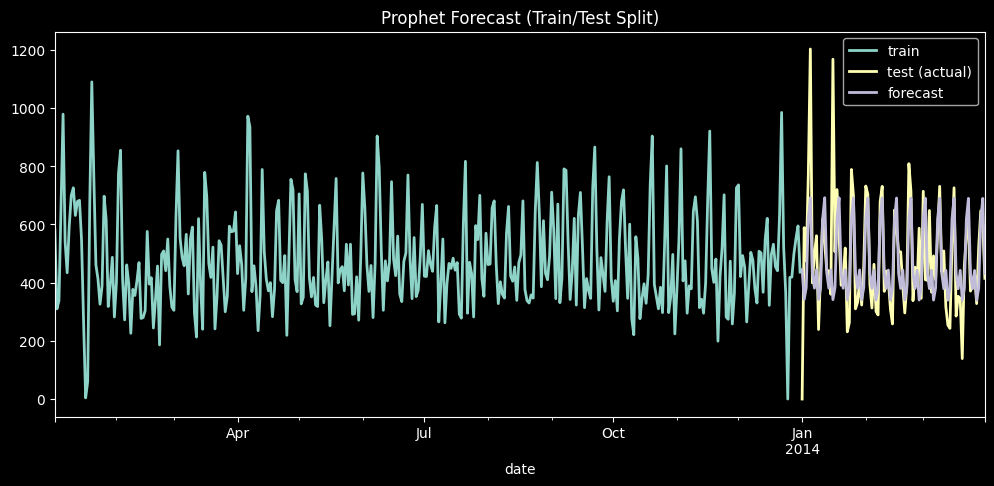

In [31]:
import matplotlib.pyplot as plt

# forecast from your fitted Prophet model
forecast = prophet_model.predict(len(test_series))

plt.figure(figsize=(12, 5))
train_series.plot(label="train")
test_series.plot(label="test (actual)")
forecast.plot(label="forecast")
plt.title("Prophet Forecast (Train/Test Split)")
plt.legend()
plt.show()

#### Models incorporating trend and weekly seasonality (ETS, SARIMA, Prophet) significantly outperform simple ARIMA and naive benchmarks. Prophet achieves the best overall performance, slightly improving upon ETS and SARIMA. This indicates that the time series exhibits strong and stable weekly seasonal structure, which is crucial for accurate forecasting.